In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving data_for_predictions.xlsx to data_for_predictions.xlsx


In [4]:
df = pd.read_excel("data_for_predictions.xlsx")

# Remove the spreadsheet index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (14606, 63)


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [5]:
print("Churn distribution:")
display(df["churn"].value_counts())

print("\nChurn percentage:")
display((df["churn"].value_counts(normalize=True) * 100).round(2))

Churn distribution:


,count
churn,
0,13187
1,1419



Churn percentage:


,proportion
churn,
0,90.28
1,9.72


In [6]:
# Separate target and predictors
y = df["churn"]
X = df.drop(columns=["id", "churn"], errors="ignore")

# Keep numeric variables for the Random Forest
X = X.select_dtypes(include=np.number).copy()

# Handle any infinite or missing values safely
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (14606, 61)
Target shape: (14606,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test churn rate:", round(y_test.mean() * 100, 2), "%")

Training set: (10954, 61)
Test set: (3652, 61)

Training churn rate: 9.71 %
Test churn rate: 9.72 %


In [8]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [9]:
# Class predictions
y_pred = model.predict(X_test)

# Probability of churn (used for ROC-AUC)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred))

Predictions generated: 3652


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

results["Score"] = results["Score"].round(3)
display(results)

,Metric,Score
0,Accuracy,0.909
1,Precision,0.824
2,Recall,0.079
3,F1 Score,0.144
4,ROC-AUC,0.697


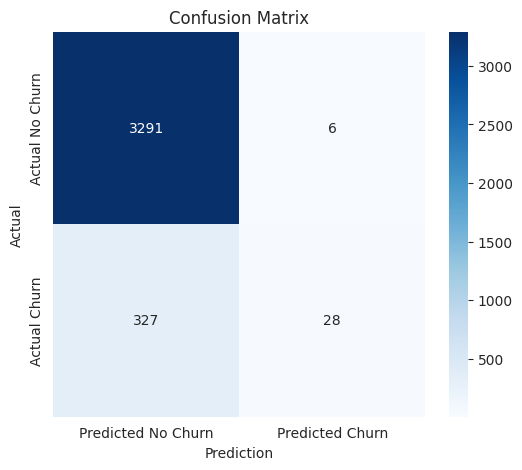

              precision    recall  f1-score   support

    No Churn       0.91      1.00      0.95      3297
       Churn       0.82      0.08      0.14       355

    accuracy                           0.91      3652
   macro avg       0.87      0.54      0.55      3652
weighted avg       0.90      0.91      0.87      3652



In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

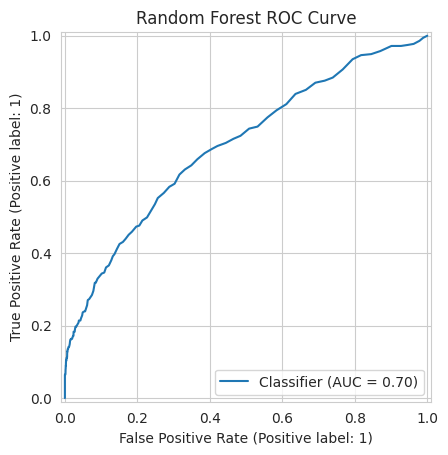

In [12]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Random Forest ROC Curve")
plt.show()

,Importance
margin_gross_pow_ele,0.052602
margin_net_pow_ele,0.051768
forecast_meter_rent_12m,0.051513
cons_12m,0.051318
net_margin,0.044592
forecast_cons_12m,0.043533
cons_last_month,0.038347
pow_max,0.033032
months_activ,0.032511
var_year_price_off_peak_var,0.031126


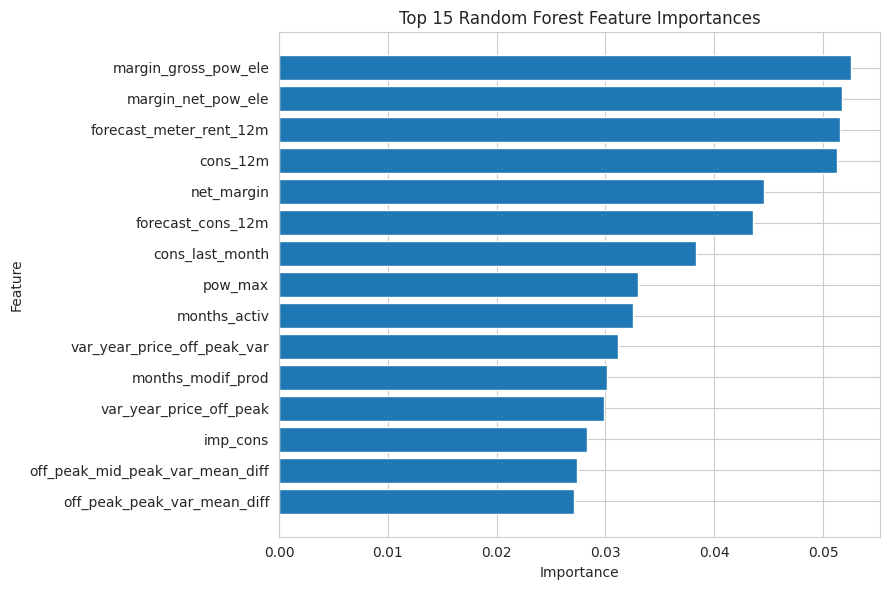

In [13]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

display(top_features.to_frame("Importance"))

plt.figure(figsize=(9, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# **Key insights and conclusion**
- The dataset is imbalanced, with churn representing a minority of customers. Therefore, accuracy should not be used alone to judge the model.
- The model's precision, recall and F1 score provide a clearer picture of how well it identifies actual churners.
- ROC-AUC provides an overall measure of the model's ability to distinguish churners from retained customers.
- The feature-importance analysis highlights the customer, consumption, margin, tenure and pricing-related variables that the Random Forest relies on most.
- A strong overall accuracy does not necessarily mean the model is satisfactory for churn prevention. If recall for churn is low, many customers who actually churn would still be missed.
- The model can therefore be used as an initial predictive model, but further tuning, threshold optimisation and additional modelling would be appropriate before using it for customer retention decisions.
Overall assessment: the model provides useful predictive signal, but performance should be judged primarily by its ability to identify the minority churn class rather than by accuracy alone.